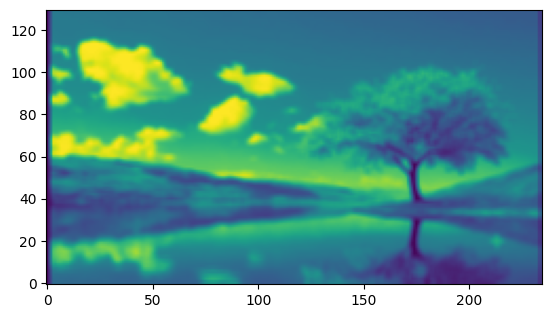

In [1]:
from PIL import Image, ImageOps, ImageEnhance
from visualisation import show_np_image, resize_image
import cv2
import numpy as np

CANVAS_SIZE = (235, 130) # mm 

# 1. Load your PIL image
pil_original_image = Image.open("../images/pink-tree-ai.png").convert("RGB").transpose(Image.FLIP_TOP_BOTTOM)

enhancer = ImageEnhance.Contrast(pil_original_image)
contrast_factor = 1.2
pil_original_image = enhancer.enhance(contrast_factor)

# 2. Resize to 440x440 (assuming resize_image is defined elsewhere)
pil_resized_image = resize_image(pil_original_image, CANVAS_SIZE)

# GaussianBlur takes a 'radius' parameter. Higher radius = more blur.
# pil_blurred_image = pil_resized_image.filter(ImageFilter.GaussianBlur(radius=5))
# np_resized_blurred_image = np.array(pil_blurred_image)

# 3. Convert the original resized PIL image to a NumPy array (if still needed)
np_resized_image = np.array(pil_resized_image)
np_original_image = np.array(pil_original_image)

gray_image = cv2.cvtColor(np_resized_image, cv2.COLOR_RGB2GRAY)
blurred_gray = cv2.GaussianBlur(gray_image, (3, 3), 10)

# Display the blurred image to verify
show_np_image(blurred_gray)

In [2]:
import matplotlib.pyplot as plt

# Edge Tangent Flow (ETF) refinement on the grayscale image.
# Start with tangents perpendicular to the image gradient and smooth them iteratively.
gray = blurred_gray.astype(np.float32)
gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)

magnitude = np.sqrt(gx**2 + gy**2)
initial_x = -gy
initial_y = gx
initial_norm = np.sqrt(initial_x**2 + initial_y**2)
initial_norm[initial_norm == 0] = 1.0
tangent_x = initial_x / initial_norm
tangent_y = initial_y / initial_norm

# Keep the refinement local so weak pixel noise does not survive.
iterations = 3
radius = 2
sigma_s = 2.0
sigma_m = float(np.percentile(magnitude, 85) + 1e-6)

height, width = gray.shape
for _ in range(iterations):
    padded_tx = np.pad(tangent_x, radius, mode="edge")
    padded_ty = np.pad(tangent_y, radius, mode="edge")
    padded_mag = np.pad(magnitude, radius, mode="edge")

    refined_x = np.zeros_like(tangent_x)
    refined_y = np.zeros_like(tangent_y)

    for y in range(height):
        for x in range(width):
            center_tx = tangent_x[y, x]
            center_ty = tangent_y[y, x]
            center_mag = padded_mag[y + radius, x + radius]

            weight_sum = 0.0
            accum_x = 0.0
            accum_y = 0.0

            for dy in range(-radius, radius + 1):
                for dx in range(-radius, radius + 1):
                    ny = y + dy + radius
                    nx = x + dx + radius

                    neighbor_tx = padded_tx[ny, nx]
                    neighbor_ty = padded_ty[ny, nx]
                    neighbor_mag = padded_mag[ny, nx]

                    spatial_distance_sq = float(dx * dx + dy * dy)
                    w_s = np.exp(-spatial_distance_sq / (2.0 * sigma_s * sigma_s))
                    w_m = 0.5 * (1.0 + np.tanh((neighbor_mag - center_mag) / sigma_m))

                    dot_product = center_tx * neighbor_tx + center_ty * neighbor_ty
                    w_d = abs(dot_product)
                    phi = 1.0 if dot_product >= 0 else -1.0

                    weight = w_s * w_m * w_d
                    accum_x += weight * neighbor_tx * phi
                    accum_y += weight * neighbor_ty * phi
                    weight_sum += weight

            if weight_sum > 0:
                refined_x[y, x] = accum_x / weight_sum
                refined_y[y, x] = accum_y / weight_sum
            else:
                refined_x[y, x] = center_tx
                refined_y[y, x] = center_ty

    tangent_x = refined_x
    tangent_y = refined_y

final_norm = np.sqrt(tangent_x**2 + tangent_y**2)
final_norm[final_norm == 0] = 1.0
unit_x = tangent_x / final_norm
unit_y = tangent_y / final_norm

# Use strong edge support to suppress flat regions and random pixel errors.
edge_map = cv2.Canny(gray.astype(np.uint8), 25, 80)
edge_map = cv2.dilate(edge_map, np.ones((3, 3), np.uint8), iterations=1)
confidence = cv2.GaussianBlur(edge_map.astype(np.float32), (0, 0), 2.0) / 255.0
confidence = np.clip(confidence, 0.0, 1.0)

In [3]:
# Sample the field on a grid so the quiver plot stays readable.
step = 5
y_positions = np.arange(0, height, step)
x_positions = np.arange(0, width, step)
xx, yy = np.meshgrid(x_positions, y_positions)

sample_x = unit_x[yy, xx]
sample_y = unit_y[yy, xx]
sample_confidence = confidence[yy, xx]

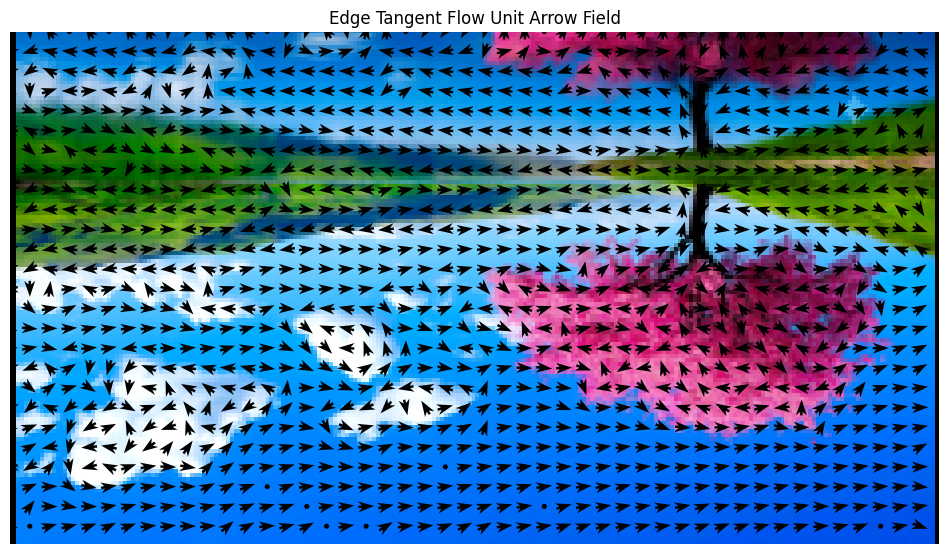